<a href="https://colab.research.google.com/github/SharpOddz/airline-systems/blob/main/Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Load in Data
#https://github.com/jpatokal/openflights
#https://openflights.org/data

In [ ]:
from io import IncrementalNewlineDecoder
import pandas as pd
from dataclasses import dataclass
from typing import List

@dataclass
class Airport:
    id: int
    name: str
    abbreviation: str
    city: str
    country: str
    latitude: float
    longitude: float

@dataclass
class Airline:
    id: int
    name: str
    abbreviation: str
    country: str

@dataclass
class Plane:
    name: str
    IATA: int
    ICAO: int

@dataclass
class Country:
    name: str
    iso_code: str

@dataclass
class Route:
    airline: str
    airline_id: int
    source_airport: str
    source_airport_id: int
    destination_airport: str
    destination_aiport_id: int
    codeshare: str
    stops: int #This is not being used apparently (it is always empty?)
    equipment: str

#Importing data
airport_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'
airlines_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airlines.dat'
planes_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/planes.dat'
routes_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'
countries_url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/countries.dat'

airport_df = pd.read_csv(airport_url, header=None)
airline_df = pd.read_csv(airlines_url, header=None)
plane_df = pd.read_csv(planes_url, header=None)
routes_df = pd.read_csv(routes_url, header=None)
countries_url = pd.read_csv(countries_url, header=None)

#Converting to dataclass lists
airport_list = []
for row in airport_df.itertuples(index=False):
  airport_obj = Airport(
    id=row[0],
    name=row[1],
    abbreviation=row[4],
    city=row[2],
    country=row[3],
    latitude=row[6],
    longitude=row[7]
  )
  airport_list.append(airport_obj)

airline_list = []
for row in airline_df.itertuples(index=False):
  airline_obj = Airline(
    id=row[0],
    name=row[1],
    abbreviation=row[2],
    country=row[6]
  )
  airline_list.append(airline_obj)

plane_list = []
for row in plane_df.itertuples(index=False):
  plane_obj = Plane(
    name=row[0],
    IATA=row[1],
    ICAO=row[2]
  )
  plane_list.append(plane_obj)

country_list = []
for row in countries_url.itertuples(index=False):
  country_obj = Country(
    name=row[0],
    iso_code=row[1]
  )
  country_list.append(country_obj)

route_list = []
for row in routes_df.itertuples(index=False):
  route_obj = Route(
    airline=row[0],
    airline_id=row[1],
    source_airport=row[2],
    source_airport_id=row[3],
    destination_airport=row[4],
    destination_aiport_id=row[5],
    codeshare=row[6],
    stops=row[7],
    equipment=row[8]
  )
  route_list.append(route_obj)

#Print out the shape
print(f'Airport Size: {len(airport_list)}')
print(f'Airline Size: {len(airline_list)}')
print(f'Plane Size: {len(plane_list)}')
print(f'Country Size: {len(country_list)}')
print(f'Route Size: {len(route_list)}')


Airport Size: 7698
Airline Size: 6162
Plane Size: 246
Country Size: 261
Route Size: 67663


# Data Validation

In [ ]:

#Data Validation, checking for missing critical values

#Airport Data Validation
missing_name_airports = [airport for airport in airport_list if not airport.name]
missing_abbr_airports = [airport for airport in airport_list if not airport.abbreviation]
missing_city_airports =  [airport for airport in airport_list if not airport.city]
missing_country_airports = [airport for airport in airport_list if not airport.country]
missing_lat_airports = [airport for airport in airport_list if airport.latitude == 0 or airport.latitude is None]
missing_long_airports = [airport for airport in airport_list if airport.longitude == 0 or airport.longitude is None]

print(f"Airports with missing name: {len(missing_name_airports)}")
print(f"Airports with missing abbreviation: {len(missing_abbr_airports)}")
print(f"Airports with missing city: {len(missing_city_airports)}")
print(f"Airports with missing country: {len(missing_country_airports)}")
print(f"Airports with missing latitude: {len(missing_lat_airports)}")
print(f"Airports with missing longitude: {len(missing_long_airports)}")

# Delete entries that do not have latitude or longitude
cleaned_airport_list = [
    airport for airport in airport_list
    if airport.latitude != 0 and airport.longitude != 0
]

print(f"\nOriginal airport count: {len(airport_list)}")
print(f"Cleaned airport count: {len(cleaned_airport_list)}")
print(f"Removed {len(airport_list) - len(cleaned_airport_list)} airports due to missing coordinates.")

# Check for invalid values remaining
invalid_lat_lon_airports = [
    airport for airport in cleaned_airport_list
    if not (-90 <= airport.latitude <= 90 and -180 <= airport.longitude <= 180)
]

print(f"Remaining airports with invalid latitude/longitude: {len(invalid_lat_lon_airports)}")


#Airline Data Validation
missing_id_airlines = [airline for airline in airline_list if not airline.id]
missing_name_airlines = [airline for airline in airline_list if not airline.name]
missing_abbr_airlines = [airline for airline in airline_list if not airline.abbreviation]
missing_country_airlines = [airline for airline in airline_list if not airline.country]
print(f"\nAirlines with missing id: {len(missing_id_airlines)}")
print(f"Airlines with missing name: {len(missing_name_airlines)}")
print(f"Airlines with missing abbreviation: {len(missing_abbr_airlines)}")
print(f"Airlines with missing country: {len(missing_country_airlines)}")

#Plane Data Validation
missing_name_planes = [plane for plane in plane_list if not plane.name]
missing_iata_planes = [plane for plane in plane_list if not plane.IATA]
missing_icao_planes = [plane for plane in plane_list if not plane.ICAO]
print(f"\nPlanes with missing name: {len(missing_name_planes)}")
print(f"Planes with missing IATA: {len(missing_iata_planes)}")
print(f"Planes with missing ICAO: {len(missing_icao_planes)}")

#Country
missing_name_countries = [country for country in country_list if not country.name]
missing_iso_countries = [country for country in country_list if not country.iso_code]
print(f"\nCountries with missing name: {len(missing_name_countries)}")
print(f"Countries with missing ISO code: {len(missing_iso_countries)}")

#Route Data Validation
missing_airline_routes = [route for route in route_list if not route.airline]
missing_airline_id_routes = [route for route in route_list if not route.airline_id]
missing_source_airport_routes = [route for route in route_list if not route.source_airport]
missing_source_airport_id_routes = [route for route in route_list if not route.source_airport_id]
missing_destination_airport_routes = [route for route in route_list if not route.destination_airport]
missing_destination_airport_id_routes = [route for route in route_list if not route.destination_aiport_id]
missing_codeshare_routes = [route for route in route_list if not route.codeshare]
missing_stops_routes = [route for route in route_list if not route.stops]
missing_equipment_routes = [route for route in route_list if not route.equipment]
print(f"\nRoutes with missing airline: {len(missing_airline_routes)}")
print(f"Routes with missing airline id: {len(missing_airline_id_routes)}")
print(f"Routes with missing source airport: {len(missing_source_airport_routes)}")
print(f"Routes with missing source airport id: {len(missing_source_airport_id_routes)}")
print(f"Routes with missing destination airport: {len(missing_destination_airport_routes)}")
print(f"Routes with missing destination airport id: {len(missing_destination_airport_id_routes)}")
print(f"Routes with missing codeshare: {len(missing_codeshare_routes)}")
print(f"Routes with missing stops: {len(missing_stops_routes)}") #Looks like stops isn't used?
print(f"Routes with missing equipment: {len(missing_equipment_routes)}")

# Filter routes to ensure they have valid source and destination airport IDs
def is_valid_route(route):
    try:
        return bool(int(route.source_airport_id)) and bool(int(route.destination_aiport_id))
    except (ValueError, TypeError):
        return False

cleaned_route_list = [route for route in route_list if is_valid_route(route)]

print(f"\nOriginal route count: {len(route_list)}")
print(f"Cleaned route count: {len(cleaned_route_list)}")
print(f"Removed {len(route_list) - len(cleaned_route_list)} routes due to missing/invalid airport IDs.")

Airports with missing name: 0
Airports with missing abbreviation: 0
Airports with missing city: 0
Airports with missing country: 0
Airports with missing latitude: 1
Airports with missing longitude: 2

Original airport count: 7698
Cleaned airport count: 7696
Removed 2 airports due to missing coordinates.
Remaining airports with invalid latitude/longitude: 0

Airlines with missing id: 0
Airlines with missing name: 0
Airlines with missing abbreviation: 0
Airlines with missing country: 0

Planes with missing name: 0
Planes with missing IATA: 0
Planes with missing ICAO: 0

Countries with missing name: 0
Countries with missing ISO code: 0

Routes with missing airline: 0
Routes with missing airline id: 0
Routes with missing source airport: 0
Routes with missing source airport id: 0
Routes with missing destination airport: 0
Routes with missing destination airport id: 0
Routes with missing codeshare: 0
Routes with missing stops: 67652
Routes with missing equipment: 0

Original route count: 676

# Feature Engineering and Graph Construction

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np

G = nx.DiGraph()

# Add nodes to the directed graph
for airport in cleaned_airport_list:
    G.add_node(
        airport.id,
        name=airport.name,
        city=airport.city,
        country=airport.country,
        lat=airport.latitude,
        lon=airport.longitude
    )

#Identify unique routes
edge_metrics = {}
for route in cleaned_route_list:
    try:
        source_id = int(route.source_airport_id)
        dest_id = int(route.destination_aiport_id)
        if G.has_node(source_id) and G.has_node(dest_id):
            edge_key = (source_id, dest_id)
            if edge_key not in edge_metrics:
                edge_metrics[edge_key] = {'count': 0, 'airlines': set()}
            edge_metrics[edge_key]['count'] += 1
            if route.airline:
                edge_metrics[edge_key]['airlines'].add(route.airline)
    except (ValueError, TypeError):
        continue

#Calculate the great-circle distance between the two points
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

for (source_id, dest_id), metrics in edge_metrics.items():
    dist = haversine(G.nodes[source_id]['lat'], G.nodes[source_id]['lon'],
                     G.nodes[dest_id]['lat'], G.nodes[dest_id]['lon'])
    G.add_edge(source_id, dest_id, weight=metrics['count'], distance=dist)

print(f"Graph constructed: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

# Use PageRank instead of Eigenvector Centrality to handle disconnected components
betweenness = nx.betweenness_centrality(G, k=500, weight='weight')
pagerank = nx.pagerank(G, weight='weight')

stats = []
for node, data in G.nodes(data=True):
    in_deg = G.in_degree(node, weight='weight')
    out_deg = G.out_degree(node, weight='weight')

    airlines = set()
    for u, v, d in G.in_edges(node, data=True): airlines.update(edge_metrics.get((u, v), {}).get('airlines', []))
    for u, v, d in G.out_edges(node, data=True): airlines.update(edge_metrics.get((u, v), {}).get('airlines', []))

    out_distances = [d['distance'] for u, v, d in G.out_edges(node, data=True)]
    avg_dist = np.mean(out_distances) if out_distances else 0

    stats.append({
        'name': data['name'],
        'country': data['country'],
        'in_degree': in_deg,
        'out_degree': out_deg,
        'distinct_airlines': len(airlines),
        'betweenness': betweenness.get(node, 0),
        'pagerank': pagerank.get(node, 0),
        'avg_flight_km': avg_dist
    })

airport_stats_df = pd.DataFrame(stats).sort_values(by='betweenness', ascending=False)
print("\nTop 10 Airports by Betweenness Centrality:")
print(airport_stats_df.head(10))

Graph constructed: 7696 nodes, 36907 edges.
Calculating centrality measures...

Top 10 Airports by Betweenness Centrality:
                                                   name        country  \
6825                        Hamad International Airport          Qatar   
3573        Ted Stevens Anchorage International Airport  United States   
1346            Charles de Gaulle International Airport         France   
3349       George Bush Intercontinental Houston Airport  United States   
191             Lester B. Pearson International Airport         Canada   
336                           Frankfurt am Main Airport        Germany   
3527              Daniel K Inouye International Airport  United States   
2435  Guarulhos - Governador André Franco Montoro In...         Brazil   
2180                       Narita International Airport          Japan   
144   Montreal / Pierre Elliott Trudeau Internationa...         Canada   

      in_degree  out_degree  distinct_airlines  betweenness  p

# Plotting Directed Graph

This only plots the unique source->destination pairs. If another airline has the same route it won't plot both of them. This is why there is a difference between number of edges/routes and the cleaned_route_list length

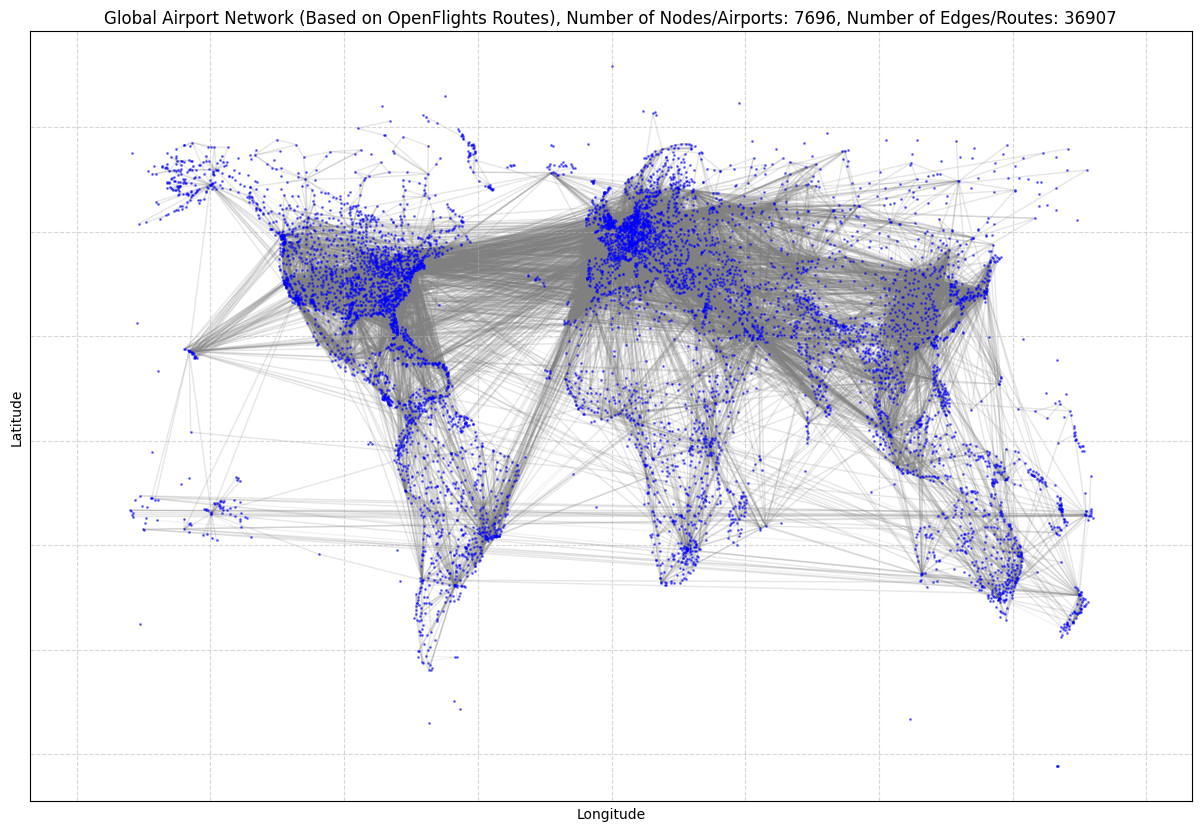

In [ ]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15, 10))

# Create a dictionary for positions based on longitude and latitude
pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=1, node_color='blue', alpha=0.5)
nx.draw_networkx_edges(G, pos, arrows=False, edge_color='gray', alpha=0.1)

plt.title(f"Global Airport Network (Based on OpenFlights Routes), Number of Nodes/Airports: {G.number_of_nodes()}, Number of Edges/Routes: {G.number_of_edges()}")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#Shows the number of unique pairs
unique_pairs = set()
for route in cleaned_route_list:
    try:
        pair = (int(route.source_airport_id), int(route.destination_aiport_id))
        unique_pairs.add(pair)
    except (ValueError, TypeError):
        continue

print(f"Number of cleaned routes: {len(cleaned_route_list)}")
print(f"Number of unique source-destination pairs: {len(unique_pairs)}")
print(f"Number of edges in G: {G.number_of_edges()}")

Number of cleaned routes: 67240
Number of unique source-destination pairs: 37274
Number of edges in G: 36907


# Unsupervised Learning (Clustering and Community Detection)

Currently using PageRank but can be switched to betweeness centrality

Detected 4506 communities.


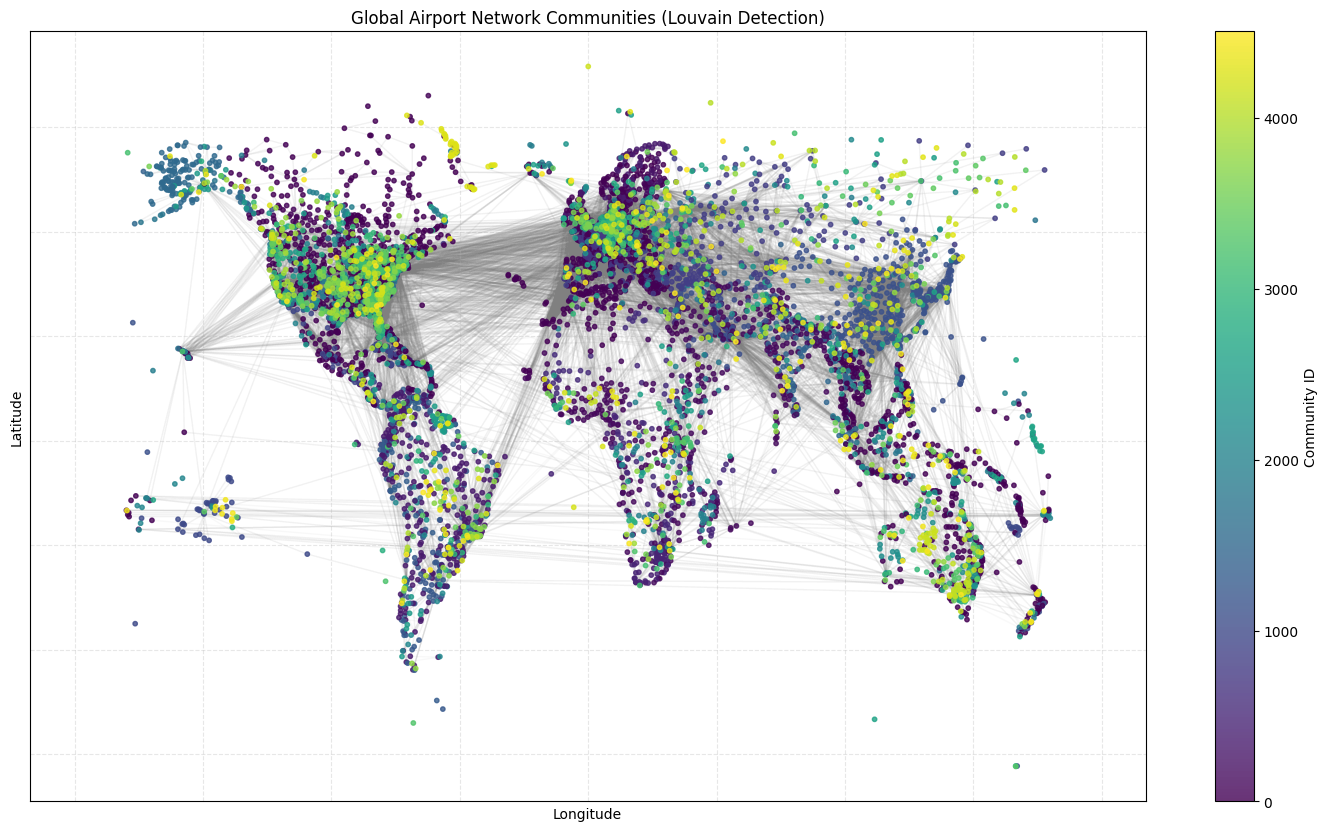


Top 3 Airports in the 5 Largest Communities (by PageRank):

Community 8:
                                                  name        country  \
3481  Hartsfield Jackson Atlanta International Airport  United States   
3629              Chicago O'Hare International Airport  United States   
3284                 Los Angeles International Airport  United States   

      pagerank  
3481  0.007922  
3629  0.004999  
3284  0.004826  

Community 4:
                                         name         country  pagerank
1346  Charles de Gaulle International Airport          France  0.004193
502                   London Heathrow Airport  United Kingdom  0.004174
336                 Frankfurt am Main Airport         Germany  0.003814

Community 0:
                                              name    country  pagerank
3123                      Singapore Changi Airport  Singapore  0.004148
3166  Sydney Kingsford Smith International Airport  Australia  0.003575
3684                          Suv

In [ ]:
import community.community_louvain as community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Louvain requires an undirected graph
G_undirected = G.to_undirected()

# Compute the best partition
partition = community_louvain.best_partition(G_undirected, weight='weight')

# Add partition to our stats dataframe
airport_stats_df['community'] = airport_stats_df.index.map(lambda x: partition.get(list(G.nodes())[x], -1))

print(f"Detected {len(set(partition.values()))} communities.")

# Plotting the communities
plt.figure(figsize=(18, 10))
pos = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}

# Use a colormap
cmap = plt.colormaps.get_cmap('viridis')

# Draw nodes colored by community
node_colors = [partition.get(node) for node in G.nodes()]
sc = nx.draw_networkx_nodes(G, pos, node_size=10, cmap=cmap, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, arrows=False, edge_color='gray', alpha=0.05)

# Add a legend/colorbar
cbar = plt.colorbar(sc)
cbar.set_label('Community ID')

plt.title("Global Airport Network Communities (Louvain Detection)")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Show top airports per community
print("\nTop 3 Airports in the 5 Largest Communities (by PageRank):")
largest_comms = airport_stats_df['community'].value_counts().head(5).index
for comm in largest_comms:
    top_in_comm = airport_stats_df[airport_stats_df['community'] == comm].sort_values(by='pagerank', ascending=False).head(3)
    print(f"\nCommunity {comm}:")
    print(top_in_comm[['name', 'country', 'pagerank']])

# Feature Matrix
Degree measures, airline count, region indicators, average route length.
Applied through K-Mean (Need to add the option for Gaussian Mixture Models)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. Prepare Feature Matrix with Log Transformation to handle skewness
features = ['in_degree', 'out_degree', 'distinct_airlines', 'avg_flight_km']
X = airport_stats_df[features].copy()

# Apply log1p (log(1+x)) to handle zeros and compress the scale of mega-hubs
X_log = np.log1p(X)

# 2. Add Region Indicators
top_countries = airport_stats_df['country'].value_counts().nlargest(15).index
X_countries = airport_stats_df['country'].apply(lambda x: x if x in top_countries else 'Other')
country_dummies = pd.get_dummies(X_countries, prefix='country')

# Combine log-scaled numeric features with indicators
X_final = pd.concat([X_log, country_dummies], axis=1)

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

# 4. K-Means Clustering - Increasing clusters to 6 for better granularity
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
airport_stats_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Feature matrix shape: {X_final.shape}")
print(f"Clusters assigned to {len(airport_stats_df)} airports.")

# Display cluster counts to check distribution
print("\nAirports per cluster:")
print(airport_stats_df['cluster'].value_counts().sort_index())

# Display cluster characteristics (using original scale for readability)
cluster_summary = airport_stats_df.groupby('cluster')[features].mean()
print("\nAverage metrics per Cluster (Original Scale):")
display(cluster_summary)

# Show sample airports from each cluster
print("\nSample Airports per Cluster:")
for i in range(n_clusters):
    print(f"\nCluster {i}:")
    display(airport_stats_df[airport_stats_df['cluster'] == i][['name', 'country', 'in_degree', 'distinct_airlines']].head(3))

Feature matrix shape: (7696, 20)
Clusters assigned to 7696 airports.

Airports per cluster:
cluster
0     425
1    3209
2    1419
3     330
4    1325
5     263
6     242
7     123
8     264
9      96
Name: count, dtype: int64

Average metrics per Cluster (Original Scale):


,in_degree,out_degree,distinct_airlines,avg_flight_km
cluster,,,,
0,2.355294,2.331765,0.962353,214.919238
1,0.437208,0.437519,0.283889,115.159036
2,40.872445,40.887245,10.749824,1205.629918
3,1.603030,1.587879,0.760606,201.138686
4,0.652830,0.652830,0.473208,94.375467
5,5.661597,5.642586,2.220532,625.642702
6,2.318182,2.322314,0.640496,138.139011
7,10.455285,10.414634,3.544715,456.176978
8,5.238636,5.250000,1.575758,298.083508



Sample Airports per Cluster:

Cluster 0:


,name,country,in_degree,distinct_airlines
158,Winnipeg / James Armstrong Richardson Internat...,Canada,40,9
152,Kuujjuaq Airport,Canada,9,2
130,Rankin Inlet Airport,Canada,23,3



Cluster 1:


...

,name,country,in_degree,distinct_airlines
2180,Narita International Airport,Japan,289,66
2256,Tokyo Haneda International Airport,Japan,158,32
3735,Chubu Centrair International Airport,Japan,85,28



Cluster 8:


,name,country,in_degree,distinct_airlines
2435,Guarulhos - Governador André Franco Montoro In...,Brazil,194,42
2431,Rio Galeão – Tom Jobim International Airport,Brazil,96,27
2449,Viracopos International Airport,Brazil,57,4



Cluster 9:


,name,country,in_degree,distinct_airlines
3776,Ministro Pistarini International Airport,Argentina,74,28
2319,Jorge Newbery Airpark,Argentina,63,7
2329,El Plumerillo Airport,Argentina,11,3


# Dimensionality Reduction (PCA)

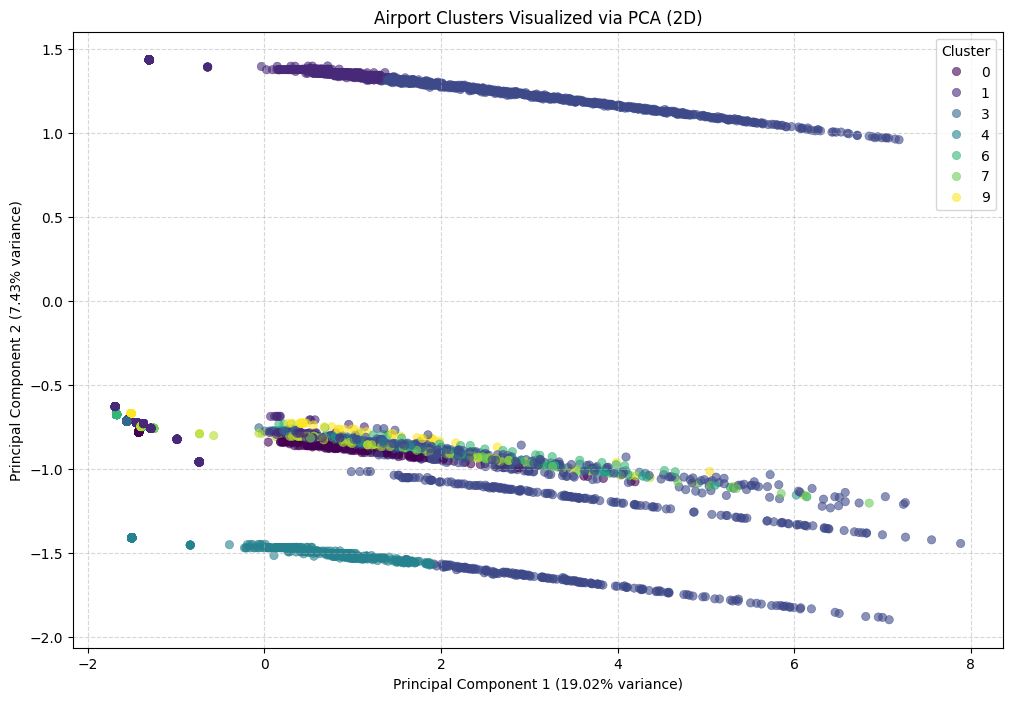

Total Explained Variance: 26.45%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# 2. Create a temporary DataFrame for plotting
plot_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
plot_df['cluster'] = airport_stats_df['cluster'].values

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    palette='viridis',
    data=plot_df,
    alpha=0.6,
    edgecolor=None
)

plt.title('Airport Clusters Visualized via PCA (2D)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.2%}")

# Heatmap Visualization
Three different heatmaps are curerntly shown, we can add more or choose one that is best

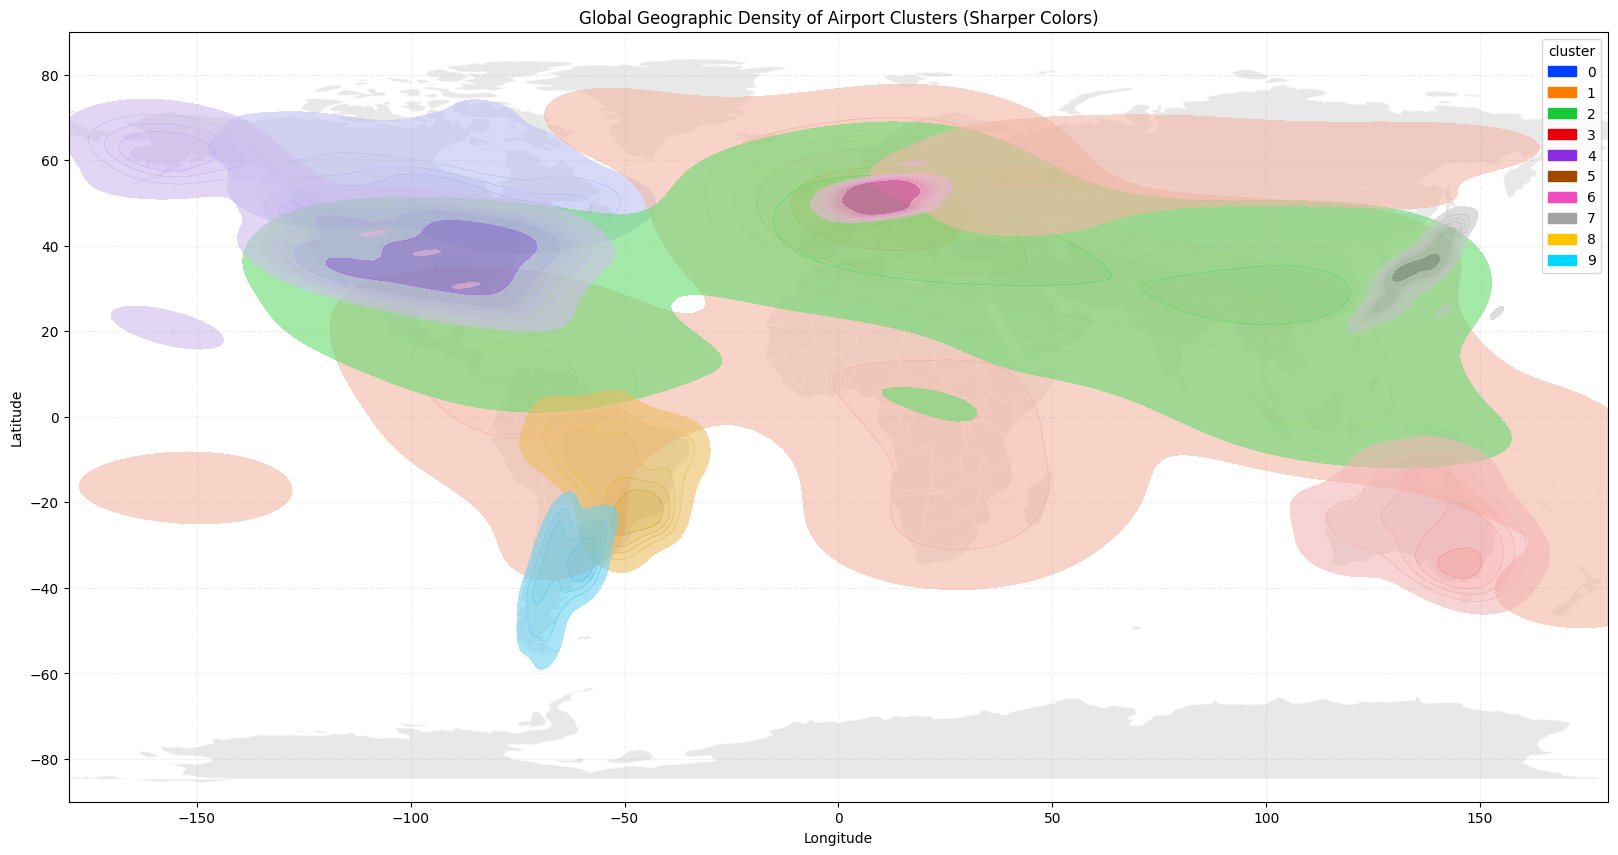

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

# Join the cluster labels back to the original coordinate data
heatmap_df = airport_stats_df.copy()
coords = {node: (data['lon'], data['lat']) for node, data in G.nodes(data=True)}
heatmap_df['lon'] = airport_stats_df.index.map(lambda x: coords[list(G.nodes())[x]][0])
heatmap_df['lat'] = airport_stats_df.index.map(lambda x: coords[list(G.nodes())[x]][1])

fig, ax = plt.subplots(figsize=(20, 10))

# Load world map from a direct URL
world_url = "https://storage.googleapis.com/codesandbox-prod-static/data/naturalearth_lowres.geojson"
try:
    world = gpd.read_file(world_url)
except:
    world = gpd.read_file("https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json")

world.plot(ax=ax, color='lightgray', edgecolor='white', alpha=0.5)

# Overlay the density plot with sharper colors ('bright' palette)
sns.kdeplot(
    data=heatmap_df,
    x='lon',
    y='lat',
    hue='cluster',
    fill=True,
    palette='bright',
    alpha=0.6,
    levels=7,
    ax=ax
)

plt.title('Global Geographic Density of Airport Clusters (Sharper Colors)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True, linestyle='--', alpha=0.2)
plt.show()

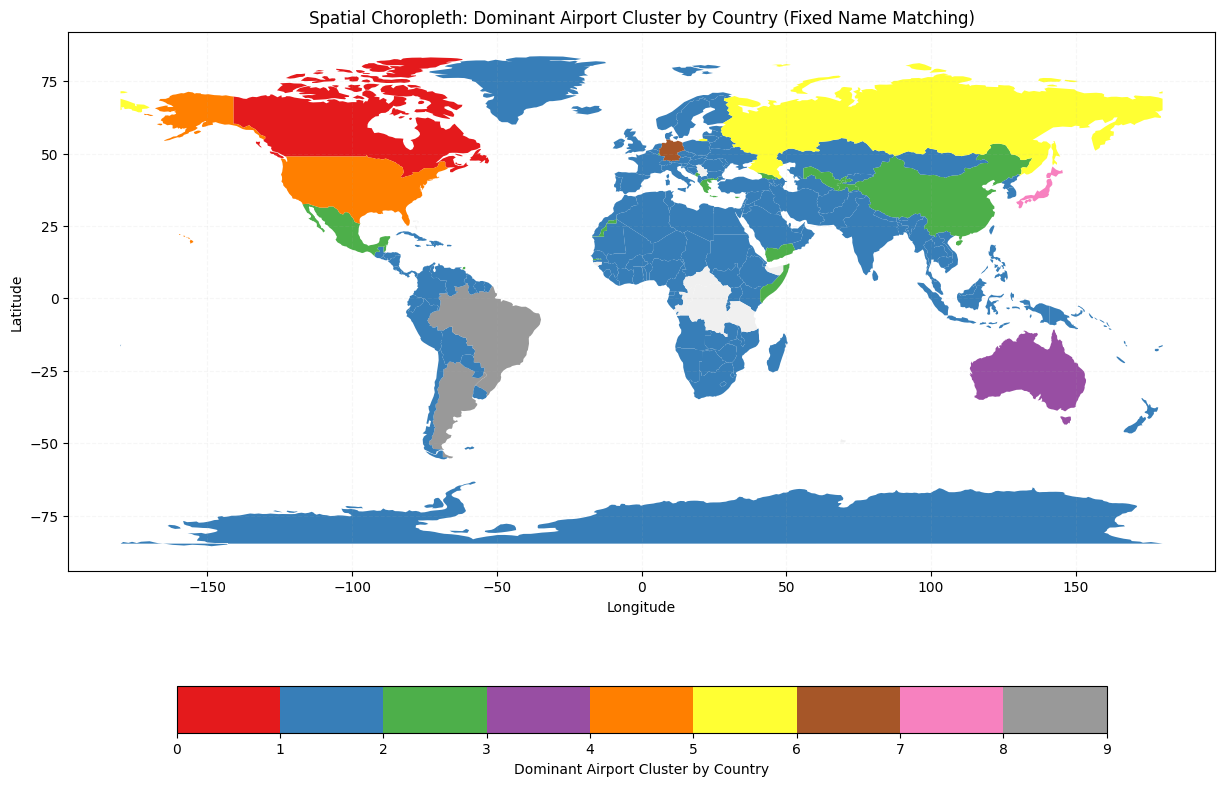

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load World Map
world_url = "https://storage.googleapis.com/codesandbox-prod-static/data/naturalearth_lowres.geojson"
try:
    world = gpd.read_file(world_url)
except:
    world = gpd.read_file("https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json")

# 2. Aggregate Cluster data by Country
country_clusters = airport_stats_df.groupby('country')['cluster'].agg(lambda x: x.mode()[0]).reset_index()

# 3. Fix Name Mismatches for better merging
name_mapping = {
    'United States': 'United States of America',
    'United Kingdom': 'United Kingdom',
    'Russian Federation': 'Russia',
    'Russia': 'Russia',
    'China': 'China',
    'Democratic Republic of the Congo': 'Dem. Rep. Congo',
    'Central African Republic': 'Central African Rep.',
    'Cote d\'Ivoire': 'Ivory Coast',
    'South Korea': 'South Korea'
}
country_clusters['country'] = country_clusters['country'].replace(name_mapping)

# 4. Merge with World Map
world_merged = world.merge(country_clusters, left_on='name', right_on='country', how='left')

# 5. Plot Choropleth
fig, ax = plt.subplots(figsize=(20, 10))
world_merged.plot(
    column='cluster',
    ax=ax,
    cmap='Set1',
    legend=True,
    missing_kwds={'color': '#f0f0f0', 'label': 'No Data'},
    legend_kwds={'label': "Dominant Airport Cluster by Country", 'orientation': "horizontal", "shrink": 0.6}
)

plt.title('Spatial Choropleth: Dominant Airport Cluster by Country (Fixed Name Matching)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.1)
plt.show()

Global Map Loaded. Total regions: 4589

Cluster distribution across US States (first 10):
       name_right  cluster
2130      Alabama        4
2131       Alaska        4
2132      Arizona        4
2133     Arkansas        4
2134   California        4
2135     Colorado        4
2136  Connecticut        4
2137     Delaware        4
2138      Florida        4
2139      Georgia        4


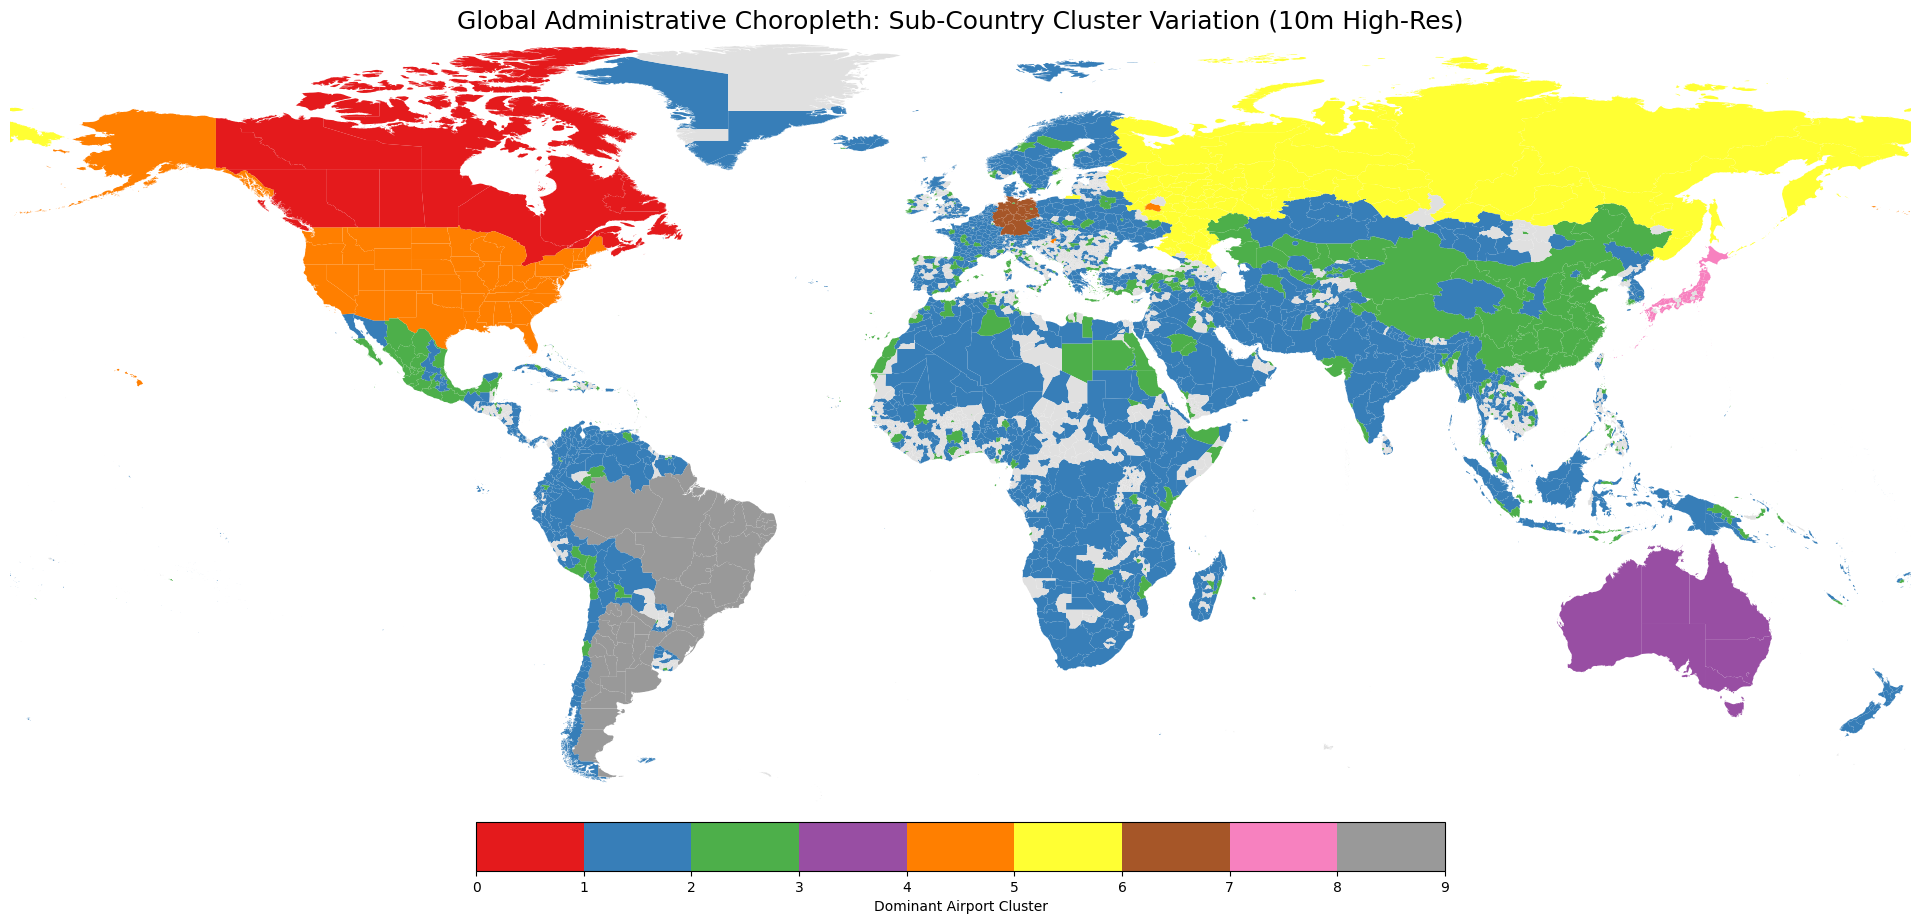

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np

# 1. Load the HIGH-RESOLUTION 10m Global States/Provinces map
states_url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson'

try:
    print("Downloading global 10m states map...")
    states_gdf = gpd.read_file(states_url)
    # Filter out common errors: ensure we have geometry and names
    states_gdf = states_gdf.dropna(subset=['geometry', 'name'])
    print(f"Global Map Loaded. Total regions: {len(states_gdf)}")
except Exception as e:
    print(f"Error: {e}")
    states_gdf = gpd.read_file('https://storage.googleapis.com/codesandbox-prod-static/data/naturalearth_lowres.geojson')

# 2. Prepare Airport GeoDataFrame
geometry = [Point(xy) for xy in zip(heatmap_df['lon'], heatmap_df['lat'])]
airports_gdf = gpd.GeoDataFrame(heatmap_df, geometry=geometry, crs='EPSG:4326')

# 3. Align Projections and Spatial Join
if states_gdf.crs is None:
    states_gdf.set_crs('EPSG:4326', inplace=True)
airports_gdf = airports_gdf.to_crs(states_gdf.crs)

# Perform spatial join using only necessary columns from states_gdf to avoid confusion
# 'name' is the state/province name, 'admin' is the country name
airports_with_regions = gpd.sjoin(airports_gdf, states_gdf[['name', 'admin', 'geometry']], how='left', predicate='within')

# 4. Aggregate Clusters by State Name AND Country (to keep states unique)
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

# Group by both admin (country) and name (state) to ensure uniqueness
region_cluster_map = airports_with_regions.groupby(['admin', 'name_right'])['cluster'].agg(get_mode).reset_index()

# 5. Merge Cluster Data back to the Global Map
# We merge on both name and country to ensure correct state mapping
states_merged = states_gdf.merge(region_cluster_map, left_on=['admin', 'name'], right_on=['admin', 'name_right'], how='left')

# 6. Debugging: Check US specific variation
us_variation = region_cluster_map[region_cluster_map['admin'] == 'United States of America']
print("\nCluster distribution across US States (first 10):")
print(us_variation[['name_right', 'cluster']].head(10))

# 7. Plot
fig, ax = plt.subplots(figsize=(25, 12))
states_merged.plot(
    column='cluster',
    ax=ax,
    cmap='Set1',
    legend=True,
    missing_kwds={'color': '#e0e0e0', 'label': 'No Data'},
    legend_kwds={'label': 'Dominant Airport Cluster', 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.02}
)

plt.title('Global Administrative Choropleth: Sub-Country Cluster Variation (10m High-Res)', fontsize=18)
plt.xlim(-180, 180)
plt.ylim(-60, 85)
plt.axis('off')
plt.show()